In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Define the path to our data file
path_1 = "mexico-city-real-estate-1.csv"
print(f'Load data from: "{path_1}"')
asf1=pd.read_csv(path_1)
asf1.head()

Load data from: "mexico-city-real-estate-1.csv"


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,NaN,54.0,NaN,101851.851900,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/o3zb...
1,sell,house,|Iztapalapa|Distrito Federal|México|,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,NaN,80.0,NaN,18900.000000,NaN,NaN,NaN,http://iztapalapa.properati.com.mx/q7t0_venta_...
2,sell,apartment,|Tlalpan|Distrito Federal|México|,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,NaN,100.0,NaN,9266.670000,NaN,NaN,NaN,http://tlalpan.properati.com.mx/qbi4_venta_dep...
3,sell,apartment,|Miguel Hidalgo|Distrito Federal|México|,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,NaN,135.0,NaN,47481.481480,NaN,NaN,NaN,http://miguel-hidalgo-df.properati.com.mx/opeq...
4,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1902642,-86.8198375",875000.0,USD,16457437.50,875000.00,0.0,263.0,NaN,3326.996198,NaN,NaN,NaN,http://cancun.properati.com.mx/hg4t_venta_depa...


In [16]:
remaining_paths = [
    "mexico-city-real-estate-2.csv",
    "mexico-city-real-estate-3.csv",
    "mexico-city-real-estate-4.csv",
    "mexico-city-real-estate-5.csv",
]

extra_dfs = []
for path in remaining_paths:
    print(f'Load data from: "{path}"')
    extra_dfs.append(pd.read_csv(path))

extra_dfs[0].head()

Load data from: "mexico-city-real-estate-2.csv"
Load data from: "mexico-city-real-estate-3.csv"
Load data from: "mexico-city-real-estate-4.csv"
Load data from: "mexico-city-real-estate-5.csv"


,operation,property_type,place_with_parent_names,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url
0,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.516777,-99.160149",1200000.0,MXN,1189144.46,63223.78,88.0,88.0,718.452046,13636.36364,NaN,NaN,NaN,http://gustavo-a-madero.properati.com.mx/r644_...
1,sell,apartment,|Gustavo A. Madero|Distrito Federal|México|,"19.466724,-99.131614",480000.0,MXN,475657.74,25289.51,NaN,48.0,NaN,10000.00000,NaN,NaN,NaN,http://vallejo.properati.com.mx/mz4c_venta_dep...
2,sell,apartment,|Álvaro Obregón|Distrito Federal|México|,"19.33228,-99.243934",4559261.0,MXN,4518016.68,240211.43,NaN,126.0,NaN,36184.61111,NaN,NaN,NaN,http://alvaro-obregon.properati.com.mx/jh8j_ve...
3,sell,apartment,|Benito Juárez|Quintana Roo|México|,"21.1105772788,-86.8537859927",3808088.0,MXN,3774533.79,200682.34,0.0,171.0,NaN,22269.52047,NaN,NaN,NaN,http://cancun.properati.com.mx/qus8_venta_depa...
4,sell,apartment,|Benito Juárez|Distrito Federal|México|,"19.39365,-99.14769",1730000.0,MXN,1714349.82,91147.61,NaN,100.0,NaN,17300.00000,NaN,NaN,NaN,http://benito-juarez.properati.com.mx/q5my_ven...


In [17]:
all_dfs = [asf1] + extra_dfs
column_match = all(set(df) == set(asf1) for df in all_dfs)
if column_match:
    print(f'The features of all {len(all_dfs)} datasets match')
    real_estate_df = pd.concat(all_dfs, ignore_index=True)
    print('Concatenation successful')
else:
    raise Exception('The features of the datasets do not match')

The features of all 5 datasets match
Concatenation successful


In [18]:
real_estate_df.shape

(23140, 16)

In [19]:
real_estate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23140 entries, 0 to 23139
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   23140 non-null  str    
 1   property_type               23140 non-null  str    
 2   place_with_parent_names     23140 non-null  str    
 3   lat-lon                     20698 non-null  str    
 4   price                       22745 non-null  float64
 5   currency                    22745 non-null  str    
 6   price_aprox_local_currency  22745 non-null  float64
 7   price_aprox_usd             22745 non-null  float64
 8   surface_total_in_m2         8633 non-null   float64
 9   surface_covered_in_m2       22215 non-null  float64
 10  price_usd_per_m2            6012 non-null   float64
 11  price_per_m2                21320 non-null  float64
 12  floor                       1531 non-null   float64
 13  rooms                       621 non-null  

In [20]:
real_estate_df.dtypes

operation                         str
property_type                     str
place_with_parent_names           str
lat-lon                           str
price                         float64
currency                          str
price_aprox_local_currency    float64
price_aprox_usd               float64
surface_total_in_m2           float64
surface_covered_in_m2         float64
price_usd_per_m2              float64
price_per_m2                  float64
floor                         float64
rooms                         float64
expenses                      float64
properati_url                     str
dtype: object

In [21]:
real_estate_df.isnull().sum()

operation                         0
property_type                     0
place_with_parent_names           0
lat-lon                        2442
price                           395
currency                        395
price_aprox_local_currency      395
price_aprox_usd                 395
surface_total_in_m2           14507
surface_covered_in_m2           925
price_usd_per_m2              17128
price_per_m2                   1820
floor                         21609
rooms                         22519
expenses                      23126
properati_url                     0
dtype: int64

In [22]:
real_estate_df = real_estate_df.drop(columns=[
    'operation', 'currency', 'price', 'price_aprox_local_currency',
    'price_usd_per_m2', 'floor', 'rooms', 'expenses',
    'properati_url', 'price_per_m2', 'surface_total_in_m2'
])

In [23]:
real_estate_df["place_with_parent_names"] = real_estate_df["place_with_parent_names"].astype("string")
real_estate_df["lat-lon"] = real_estate_df["lat-lon"].astype("string")

real_estate_df = (
    real_estate_df.assign(
        state=lambda x: x["place_with_parent_names"].str.split("|", expand=True)[2],
        lat=lambda x: pd.to_numeric(x["lat-lon"].str.split(",").str[0], errors="coerce"),
        lon=lambda x: pd.to_numeric(x["lat-lon"].str.split(",").str[1], errors="coerce"),
    )
    .drop(columns=["place_with_parent_names", "lat-lon"])
    .dropna()
)

In [24]:

real_estate_df 


,property_type,price_aprox_usd,surface_covered_in_m2,state,lat,lon
0,apartment,289775.66,54.0,Distrito Federal,23.634501,-102.552788
1,house,79661.96,80.0,Distrito Federal,19.310330,-99.068557
2,apartment,48822.82,100.0,Distrito Federal,19.279771,-99.234597
3,apartment,337720.36,135.0,Distrito Federal,23.634501,-102.552788
4,apartment,875000.00,263.0,Quintana Roo,21.190264,-86.819838
...,...,...,...,...,...,...
23134,apartment,14421.44,53.0,Benito Juárez,21.187961,-86.839487
23135,apartment,92000.00,48.0,Quintana Roo,20.500732,-87.223581
23136,house,37229.08,105.0,Distrito Federal,19.342911,-99.224472
23137,apartment,32764.67,130.0,Distrito Federal,19.408758,-99.129474


In [25]:
real_estate_df.to_csv("mexico-real-estate-combined-clean.csv", index=False)

Text(0, 0.5, 'Frequency')

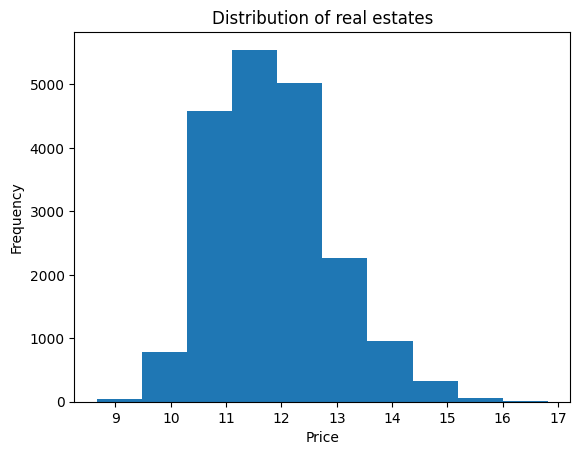

In [26]:
fig,ax=plt.subplots()
ax.hist(np.log1p(real_estate_df['price_aprox_usd'])) # We take log of price to better visualize the distribution we take log1p because log can't handle 0 but log1p(x) can because it handles 1+x
ax.set_title('Distribution of real estates')
ax.set_xlabel('Price')
ax.set_ylabel('Frequency')

Text(0.5, 0, 'Covered Surface Area')

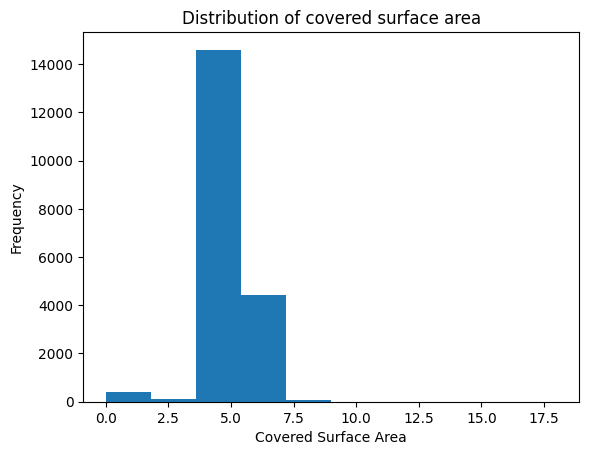

In [27]:
fig,ax=plt.subplots()
ax.hist(np.log1p(real_estate_df['surface_covered_in_m2']))
ax.set_title('Distribution of covered surface area')
ax.set_ylabel('Frequency')
ax.set_xlabel('Covered Surface Area')

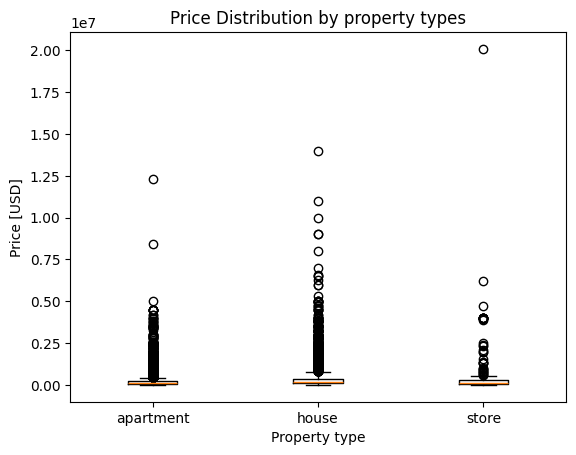

In [28]:
property_types = real_estate_df['property_type'].unique()
data_by_type = [real_estate_df[real_estate_df['property_type'] == ptype]["price_aprox_usd"] for ptype in property_types]
fig, ax = plt.subplots()
ax.boxplot(data_by_type, tick_labels=property_types)
ax.set_title('Price Distribution by property types')
ax.set_xlabel('Property type')
ax.set_ylabel('Price [USD]')
plt.show()

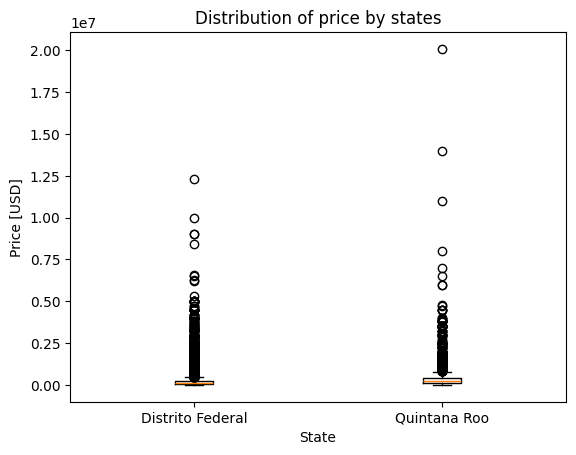

In [29]:
topstates=(real_estate_df['state']
    .value_counts()
    .head(2)
    .index.tolist())

data_state=[real_estate_df[real_estate_df['state']==state]["price_aprox_usd"] for state in topstates]
fig, ax= plt.subplots()
ax.boxplot(data_state,tick_labels=topstates)
ax.set_title("Distribution of price by states")
ax.set_xlabel("State")
ax.set_ylabel("Price [USD]")
plt.show()

In [30]:
lower_limit = 0.05
upper_limit = 0.95
df = real_estate_df
df_clean = (
    df[
        (df["price_aprox_usd"] > df["price_aprox_usd"].quantile(lower_limit)) &
        (df["price_aprox_usd"] < df["price_aprox_usd"].quantile(upper_limit)) &
        (df["surface_covered_in_m2"] > df["surface_covered_in_m2"].quantile(lower_limit)) &
        (df["surface_covered_in_m2"] < df["surface_covered_in_m2"].quantile(upper_limit))
    ]
)

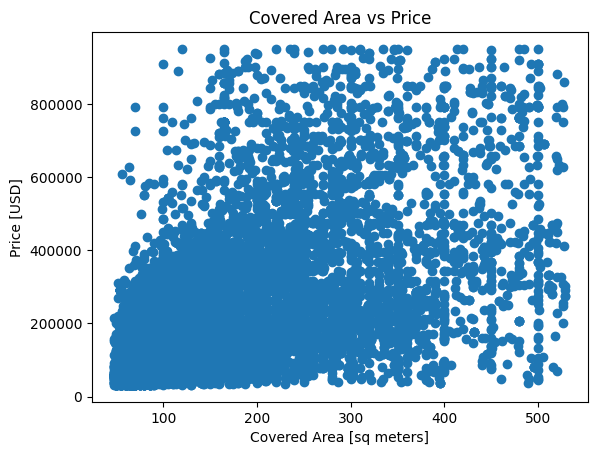

In [31]:
fig, ax = plt.subplots()
ax.scatter(df_clean["surface_covered_in_m2"], df_clean["price_aprox_usd"])
ax.set_title("Covered Area vs Price")
ax.set_xlabel("Covered Area [sq meters]")
ax.set_ylabel("Price [USD]")
plt.show()

<Axes: xlabel='surface_covered_in_m2', ylabel='price_aprox_usd'>

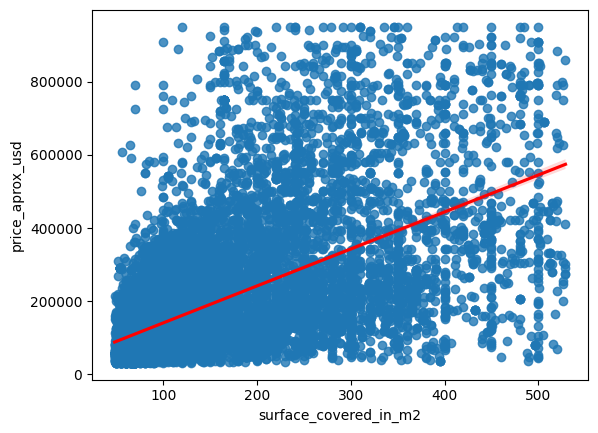

In [32]:
import seaborn as sns
fig, ax = plt.subplots()
sns.regplot(
    data=df_clean,
    x="surface_covered_in_m2",
    y="price_aprox_usd",
    line_kws={"color": "red"},
)

In [33]:
mean_state=df.groupby('state')['price_aprox_usd'].mean().sort_values()

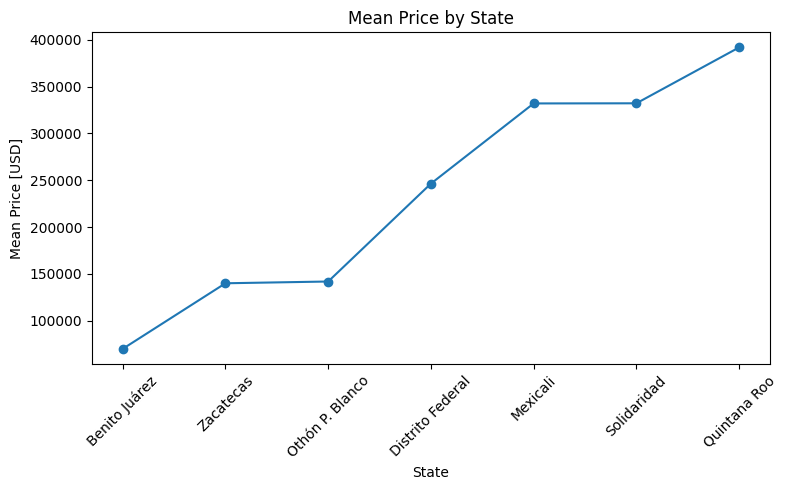

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mean_state.index, mean_state.values, marker="o")
ax.set_title("Mean Price by State")
ax.set_xlabel("State")
ax.set_ylabel("Mean Price [USD]")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

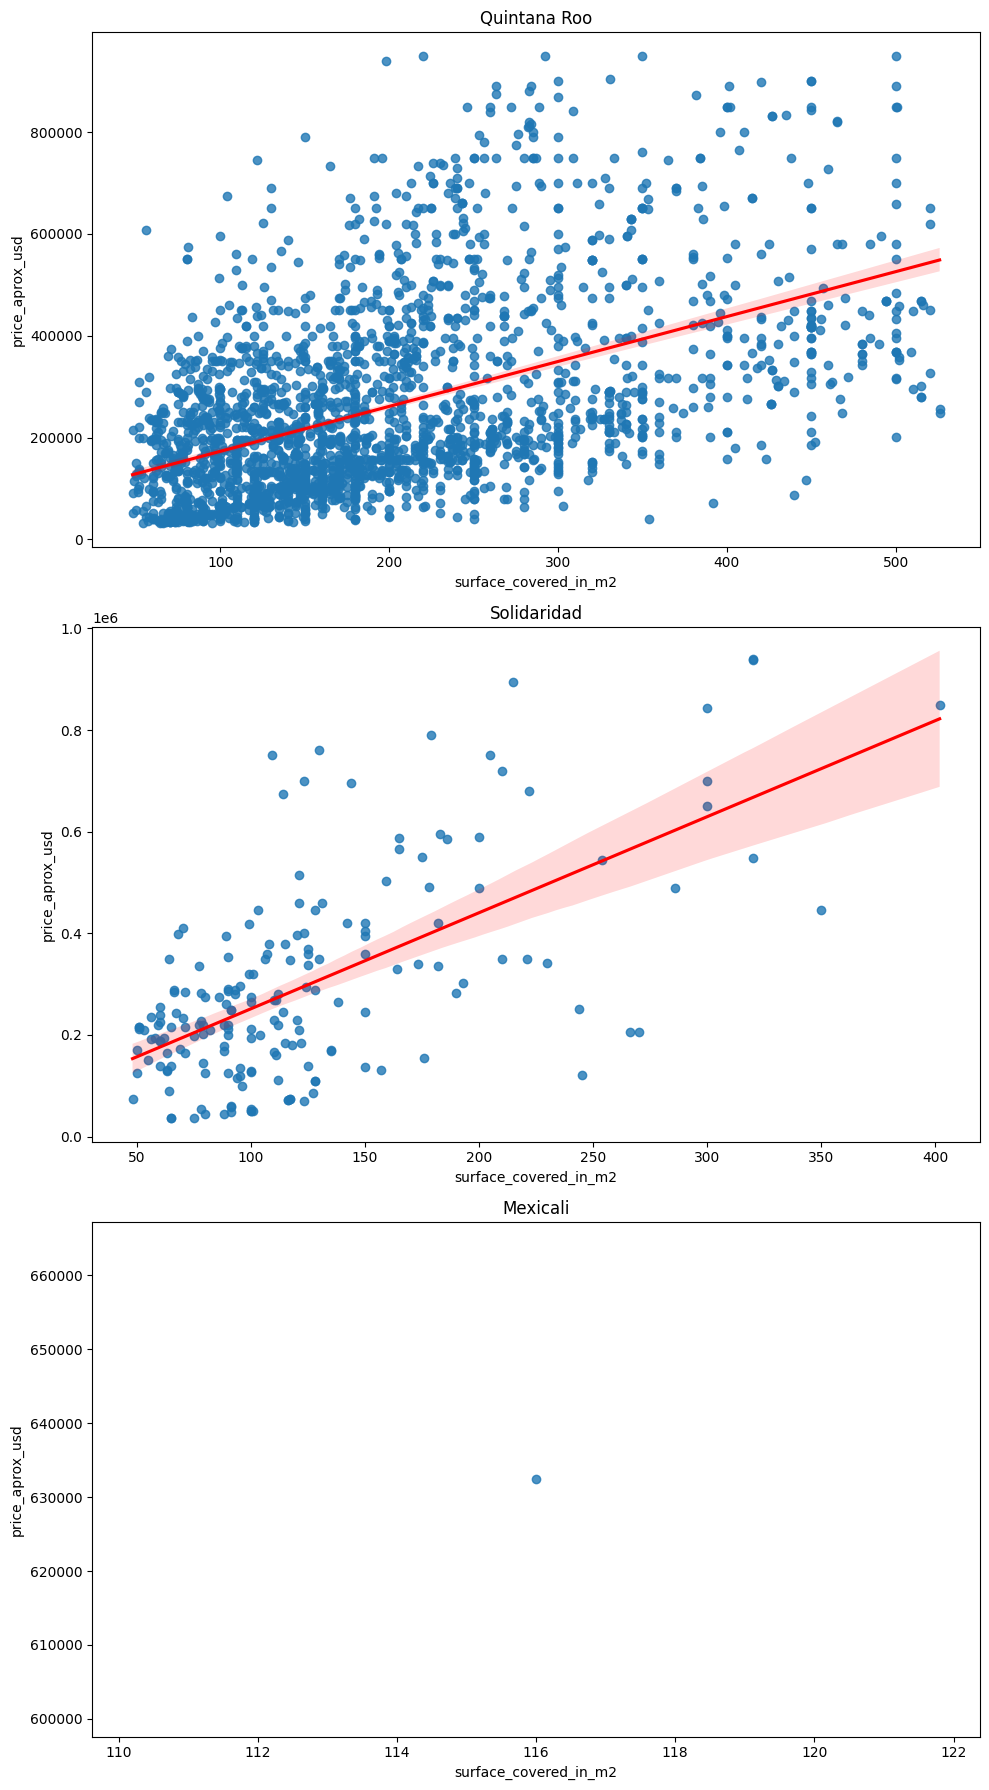

In [35]:
top_mean_states = (
    real_estate_df.groupby("state")["price_aprox_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

n = len(top_mean_states)
fig, axes = plt.subplots(n, 1, figsize=(10, 6 * n))
if n == 1:
    axes = [axes]

for ax, state in zip(axes, top_mean_states):
    sample = df_clean[df_clean["state"] == state]
    sns.regplot(
        data=sample,
        x="surface_covered_in_m2",
        y="price_aprox_usd",
        line_kws={"color": "red"},
        ax=ax,
    )
    ax.set_title(state)
plt.tight_layout()
plt.show()

In [36]:
print(f"Mean price by state:\n{mean_state.to_string()}")

Mean price by state:
state
Benito Juárez        70128.683182
Zacatecas           140094.100000
Othón P. Blanco     141983.114000
Distrito Federal    246418.427670
Mexicali            331967.590000
Solidaridad         332111.471140
Quintana Roo        391749.796584


In [37]:
corr_price_area=real_estate_df["surface_covered_in_m2"].corr(real_estate_df['price_aprox_usd'])
print(f'The correlation between area and price of property is {corr_price_area}')

The correlation between area and price of property is -0.0029680489487523476


In [38]:
corr_matrix = (
    real_estate_df
    .select_dtypes("number") # to select the numeric data only
    .corr()
)

corr_matrix

,price_aprox_usd,surface_covered_in_m2,lat,lon
price_aprox_usd,1.000000,-0.002968,0.069226,0.095353
surface_covered_in_m2,-0.002968,1.000000,-0.002651,-0.001938
lat,0.069226,-0.002651,1.000000,0.547948
lon,0.095353,-0.001938,0.547948,1.000000


Text(0.5, 1.0, 'Correlation Matrix for numerical features of Real Estate Data')

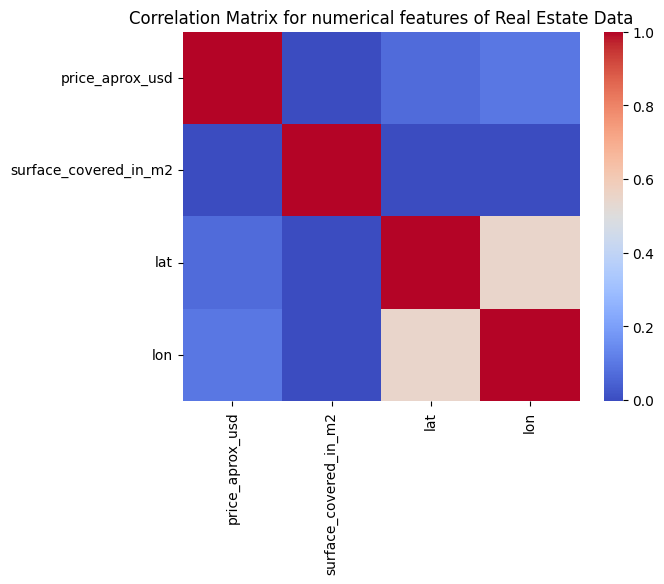

In [39]:
fig,ax=plt.subplots()
sns.heatmap(corr_matrix,cmap='coolwarm',ax=ax)
ax.set_title('Correlation Matrix for numerical features of Real Estate Data')

In [40]:
(real_estate_df.groupby("state")[['surface_covered_in_m2','price_aprox_usd']]
 .corr()
 .iloc[:,1]
 .xs('surface_covered_in_m2',level=1))


state
Benito Juárez       0.585003
Distrito Federal   -0.003253
Mexicali            1.000000
Othón P. Blanco     0.891738
Quintana Roo       -0.004936
Solidaridad         0.527726
Zacatecas           0.383262
Name: price_aprox_usd, dtype: float64

In [41]:
(real_estate_df.groupby('property_type')[['surface_covered_in_m2','price_aprox_usd']]
 .corr()
 .iloc[:,1]
 .xs('surface_covered_in_m2',level=1)
)



property_type
apartment   -0.004021
house        0.000471
store        0.542884
Name: price_aprox_usd, dtype: float64

In [42]:
data = (
    real_estate_df
    .assign(price_per_m2=lambda x: x["price_aprox_usd"] / x["surface_covered_in_m2"])
)

print(f"Shape before filter: {data.shape}")
print(data.head())
print()

data = data[
    (data["surface_covered_in_m2"] < 5000) &
    (data["price_per_m2"] < 20000)
]
print(f"Shape after filter: {data.shape}")

Shape before filter: (19613, 7)
  property_type  price_aprox_usd  surface_covered_in_m2             state  \
0     apartment        289775.66                   54.0  Distrito Federal   
1         house         79661.96                   80.0  Distrito Federal   
2     apartment         48822.82                  100.0  Distrito Federal   
3     apartment        337720.36                  135.0  Distrito Federal   
4     apartment        875000.00                  263.0      Quintana Roo   

         lat         lon  price_per_m2  
0  23.634501 -102.552788   5366.215926  
1  19.310330  -99.068557    995.774500  
2  19.279771  -99.234597    488.228200  
3  23.634501 -102.552788   2501.632296  
4  21.190264  -86.819838   3326.996198  

Shape after filter: (19171, 7)


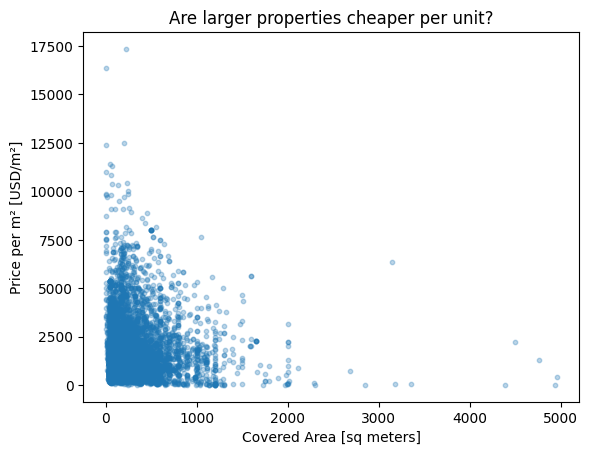

In [43]:
fig, ax = plt.subplots()
ax.scatter(data["surface_covered_in_m2"], data["price_per_m2"], alpha=0.3, s=10)
ax.set_title("Are larger properties cheaper per unit?")
ax.set_xlabel("Covered Area [sq meters]")
ax.set_ylabel("Price per m² [USD/m²]")
plt.show()

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("scikit-learn imports successful")

scikit-learn imports successful


In [ ]:
y = real_estate_df["price_aprox_usd"]

X = real_estate_df[["surface_covered_in_m2", "property_type", "state"]].copy()

for col in ["property_type", "state"]:
    top_level = X[col].value_counts().idxmax()
    ordered_levels = [top_level] + sorted(lv for lv in X[col].unique() if lv != top_level)
    X[col] = pd.Categorical(X[col], categories=ordered_levels)

X = pd.get_dummies(
    X,
    columns=["property_type", "state"],
    drop_first=True,
    dtype=float,
)

print("Feature matrix shape:", X.shape)
print("Target vector length:", len(y))
print()
print("Feature columns:")
print(X.columns.tolist())
print()
print("Feature matrix head:")
X.head()

Feature matrix shape: (19613, 9)
Target vector length: 19613

Feature columns:
['surface_covered_in_m2', 'property_type_house', 'property_type_store', 'state_Benito Juárez', 'state_Mexicali', 'state_Othón P. Blanco', 'state_Quintana Roo', 'state_Solidaridad', 'state_Zacatecas']

Feature matrix head:


,surface_covered_in_m2,property_type_house,property_type_store,state_Benito Juárez,state_Mexicali,state_Othón P. Blanco,state_Quintana Roo,state_Solidaridad,state_Zacatecas
0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,80.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,135.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,263.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [46]:
y_log = np.log1p(y)

print("Raw target summary:")
print(y.describe())
print()
print("Log-target summary:")
print(pd.Series(y_log).describe())

Raw target summary:
count    1.961300e+04
mean     2.699108e+05
std      5.236859e+05
min      5.796880e+03
25%      6.217005e+04
50%      1.300000e+05
75%      2.590000e+05
max      2.008064e+07
Name: price_aprox_usd, dtype: float64

Log-target summary:
count    19613.000000
mean        11.836807
std          1.057175
min          8.665248
25%         11.037645
50%         11.775297
75%         12.464587
max         16.815267
Name: price_aprox_usd, dtype: float64


In [47]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.20,
    random_state=42,
)

y_train = np.expm1(y_train_log)
y_test = np.expm1(y_test_log)

print(f"Training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} rows, {X_test.shape[1]} features")

Training set: 15690 rows, 9 features
Test set:     3923 rows, 9 features


Linear Regression Model

In [48]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train_log)

print("Model fitted.")
print(f"Intercept (β₀): {model.intercept_:.4f}")
print(f"Number of fitted coefficients: {len(model.coef_)}")

Model fitted.
Intercept (β₀): 11.5934
Number of fitted coefficients: 9


In [49]:
# Predictions on the log-target scale
y_train_pred_log = model.predict(X_train)
y_test_pred_log = model.predict(X_test)

# Back-transform to USD for interpretable RMSE
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

# RMSE in USD
rmse_train_usd = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test_usd = np.sqrt(mean_squared_error(y_test, y_test_pred))

# R² on the log-target scale
r2_train = r2_score(y_train_log, y_train_pred_log)
r2_test = r2_score(y_test_log, y_test_pred_log)

print(f"{'Metric':<28}{'Train':>15}{'Test':>15}")
print("-" * 58)
print(f"{'RMSE [USD]':<28}{rmse_train_usd:>15,.0f}{rmse_test_usd:>15,.0f}")
print(f"{'R² (log-target)':<28}{r2_train:>15.4f}{r2_test:>15.4f}")

Metric                                Train           Test
----------------------------------------------------------
RMSE [USD]                          540,495        490,796
R² (log-target)                      0.0999         0.1110


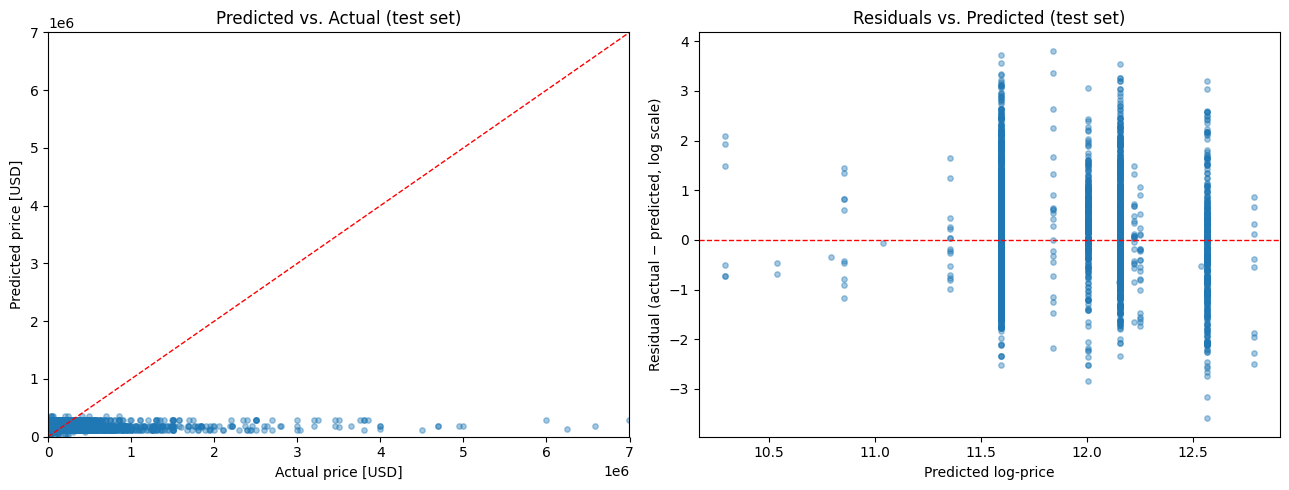

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs. actual, in USD, on the test set
axes[0].scatter(y_test, y_test_pred, alpha=0.4, s=15)
lims = [0, max(y_test.max(), y_test_pred.max())]
axes[0].plot(lims, lims, color="red", linestyle="--", linewidth=1)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual price [USD]")
axes[0].set_ylabel("Predicted price [USD]")
axes[0].set_title("Predicted vs. Actual (test set)")

# Residuals vs. predicted, on the log scale the model was fit on
residuals_log = y_test_log - y_test_pred_log
axes[1].scatter(y_test_pred_log, residuals_log, alpha=0.4, s=15)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted log-price")
axes[1].set_ylabel("Residual (actual − predicted, log scale)")
axes[1].set_title("Residuals vs. Predicted (test set)")

plt.tight_layout()
plt.show()

In [51]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_,
})

# Compute percentage effect. For a 1-unit change in a feature, the multiplier on price is exp(coef).
coef_df["pct_effect"] = (np.exp(coef_df["coef"]) - 1) * 100
coef_df["direction"] = np.where(coef_df["coef"] >= 0, "+", "−")

print("Intercept (reference: apartment in Distrito Federal, area = 0):")
print(f"  β₀ = {model.intercept_:.4f}")
print()
print("Feature coefficients:")
print(coef_df.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

Intercept (reference: apartment in Distrito Federal, area = 0):
  β₀ = 11.5934

Feature coefficients:
              feature    coef  pct_effect direction
surface_covered_in_m2 -0.0000     -0.0000         −
  property_type_house +0.5625    +75.4985         +
  property_type_store +0.2448    +27.7410         +
  state_Benito Juárez -1.2988    -72.7130         −
       state_Mexicali -0.0163     -1.6183         −
state_Othón P. Blanco -0.4333    -35.1662         −
   state_Quintana Roo +0.4104    +50.7458         +
    state_Solidaridad +0.6292    +87.6093         +
      state_Zacatecas -0.8005    -55.0894         −
